# Results Analysis — Best Neural Network Model

Best config: **hidden=[128, 64, 32], lr=0.001, dropout=0.1**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

plt.rcParams["figure.dpi"] = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
class YieldNet(nn.Module):
    def __init__(self, input_dim=6, hidden_sizes=(128, 64, 32), dropout=0.1):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

    def predict(self, X):
        self.eval()
        with torch.no_grad():
            return self(torch.tensor(X, dtype=torch.float32).to(device)).cpu().numpy().flatten()

    def fit(self, X, y):
        return self

In [3]:
df = pd.read_csv("../data/yield_data.csv")
X = df.drop(columns=["yield_percent"]).values.astype(np.float32)
y = df["yield_percent"].values.astype(np.float32).reshape(-1, 1)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

feature_names = ["temperature_C", "pressure_mTorr", "gas_flow_sccm",
                 "rf_power_W", "deposition_time_s", "chamber_humidity"]

model = YieldNet(hidden_sizes=[128, 64, 32], dropout=0.1).to(device)
model.load_state_dict(torch.load("../models/yield_net_best.pt", map_location=device))
model.eval()
print("Model loaded from models/yield_net_best.pt")

Model loaded from models/yield_net_best.pt


/var/folders/6b/7vg7v5l54b57_g4dn2nvvcqm0000gn/T/ipykernel_65911/3184514463.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../models/

## 1. Train vs Validation Loss Curves

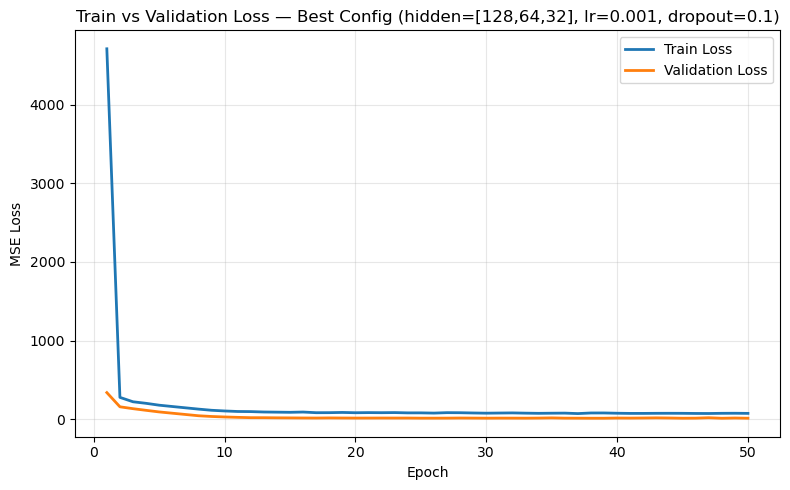

Saved to results/loss_curves.png


In [4]:
loss_df = pd.read_csv("../results/best_config_loss_history.csv")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(loss_df["epoch"], loss_df["train_loss"], label="Train Loss", linewidth=2)
ax.plot(loss_df["epoch"], loss_df["val_loss"], label="Validation Loss", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Train vs Validation Loss — Best Config (hidden=[128,64,32], lr=0.001, dropout=0.1)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/loss_curves.png", dpi=150)
plt.show()
print("Saved to results/loss_curves.png")

## 2. Predicted vs Actual Yield

Test RMSE: 3.5638
Test R²:   0.8608


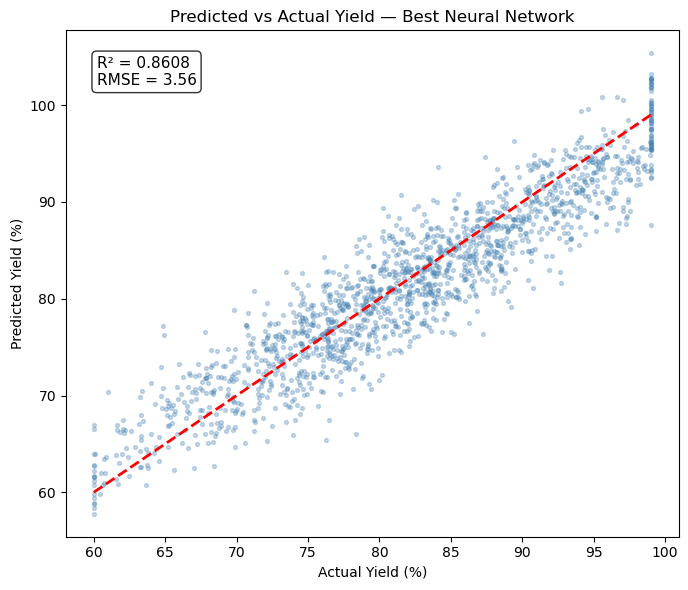

Saved to results/nn_predictions.png


In [5]:
y_test_np = y_test.flatten()
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test_np, y_pred))
r2 = r2_score(y_test_np, y_pred)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²:   {r2:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_np, y_pred, alpha=0.3, s=8, color="steelblue")
ax.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], "r--", lw=2)
ax.set_xlabel("Actual Yield (%)")
ax.set_ylabel("Predicted Yield (%)")
ax.set_title("Predicted vs Actual Yield — Best Neural Network")
ax.text(0.05, 0.95, f"R² = {r2:.4f}\nRMSE = {rmse:.2f}", transform=ax.transAxes,
        fontsize=11, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.tight_layout()
plt.savefig("../results/nn_predictions.png", dpi=150)
plt.show()
print("Saved to results/nn_predictions.png")

## 3. Permutation Feature Importance

          Feature  Importance      Std
 chamber_humidity    0.027076 0.003384
       rf_power_W    0.122243 0.005884
    gas_flow_sccm    0.145035 0.007450
    temperature_C    0.185694 0.008023
   pressure_mTorr    0.374195 0.013061
deposition_time_s    0.880477 0.025728


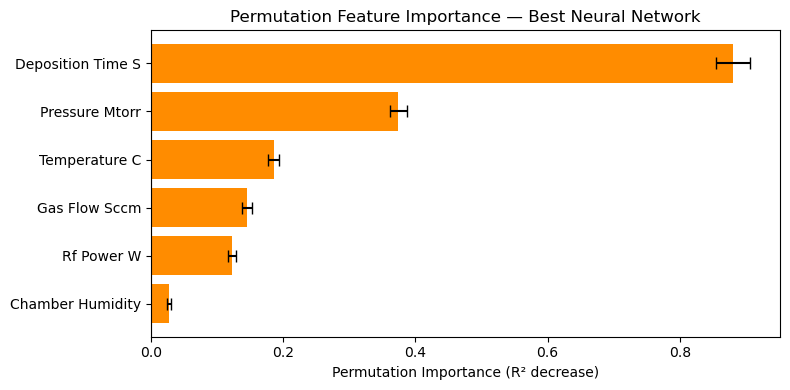

Saved to results/permutation_importance.png
Saved to results/permutation_importance.csv


In [6]:
def score_fn(est, X, y):
    y_pred = est.predict(X)
    return r2_score(y, y_pred)

X_test_subset = X_test[:1600]
y_test_subset = y_test_np[:1600]

result = permutation_importance(
    estimator=model,
    X=X_test_subset,
    y=y_test_subset,
    scoring=score_fn,
    n_repeats=10,
    random_state=42,
    n_jobs=1,
)

importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": result.importances_mean,
    "Std": result.importances_std,
}).sort_values("Importance", ascending=True)

print(importances.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importances["Feature"].str.replace("_", " ").str.title(),
        importances["Importance"], xerr=importances["Std"],
        color="darkorange", capsize=4)
ax.set_xlabel("Permutation Importance (R² decrease)")
ax.set_title("Permutation Feature Importance — Best Neural Network")
ax.axvline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.savefig("../results/permutation_importance.png", dpi=150)
plt.show()
print("Saved to results/permutation_importance.png")

importances.to_csv("../results/permutation_importance.csv", index=False)
print("Saved to results/permutation_importance.csv")